[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/Entornos_Complejos/sarsa_semi_gradient.ipynb)

# Estudio Comparativo Completo: Semi-Gradient SARSA en Flappy Bird

## ¿Qué es SARSA Semi-Gradiente?

SARSA (State-Action-Reward-State-Action) es un algoritmo de control on-policy de diferencias temporales (TD). Aprende una función de valor-acción $\hat{q}(s, a, w)$ que estima la recompensa futura esperada al tomar la acción $a$ en el estado $s$.

### Regla de Actualización

La actualización semi-gradiente de SARSA sigue esta fórmula:

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \Big[ R_{t+1} + \gamma \hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w}) \Big] \nabla_{\mathbf{w}} \hat{q}(S_t, A_t, \mathbf{w})$$

Donde:
- $\mathbf{w}$: pesos de la red neuronal que parametriza $\hat{q}$
- $\alpha$: tasa de aprendizaje (learning rate)
- $\gamma$: factor de descuento (cuánto valoramos recompensas futuras)
- $R_{t+1}$: recompensa observada tras la transición
- $\hat{q}(S_t, A_t, \mathbf{w})$: Q-value actual (con gradientes)
- $\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w})$: Q-value del siguiente par estado-acción (sin gradientes, tratado como constante)

### ¿Por qué Red Neuronal en vez de Tabla?

Flappy Bird tiene un espacio de estados continuo de 12 dimensiones (posición, velocidad, distancias a tubos...). Una tabla Q requeriría discretizar todas las dimensiones, lo que produciría una tabla demasiado grande o demasiado imprecisa. Una red neuronal puede generalizar entre estados similares.

### Nuestra Arquitectura

```
Input (12 dims) → FC(64) → ReLU → FC(64) → ReLU → FC(2 acciones)
```

La red recibe el vector de observación del entorno y produce los Q-values para las 2 acciones posibles: no hacer nada (0) o saltar (1).

### Replay Buffer y la Cuestión On-Policy vs Off-Policy

SARSA es inherentemente on-policy: aprende sobre la política que está siguiendo actualmente. Al usar un Replay Buffer, las experiencias almacenadas provienen de políticas antiguas (con diferente $\epsilon$), lo cual introduce un sesgo off-policy. Sin embargo, en la práctica esto:
- Reduce la varianza (al promediar muchas experiencias)
- Evita el olvido catastrófico (catastophic forgetting: la red machaca pesos al entrenar sólo con la transición más reciente)
- Acelera la convergencia significativamente

In [ ]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [ ]:
!pip install -q gymnasium flappy-bird-gymnasium torch numpy matplotlib seaborn pygame tqdm pandas

In [ ]:
!cd GallegoSalgueiroVera/Entornos_Complejos && pwd

In [ ]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, clear_output
import torch

project_root = os.path.abspath('GallegoSalgueiroVera/Entornos_Complejos')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.envs.flappy_bird import make_flappy_bird_env
from src.agents.td_agents_sarsa_sg import SemiGradientSarsaAgent
from src.agents.replay_buffer import ReplayBuffer
from src.plotting.plotting import evaluate_flappy_bird_agent

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


In [2]:
# === CONFIGURACION GLOBAL ===
ALPHA_REWARD = 0.1        # Peso del reward shaping (cercanía al centro del gap)
LEARNING_RATE = 1e-3      # α - tasa de aprendizaje para el optimizador Adam
GAMMA = 0.99              # γ - factor de descuento
EPSILON_START = 0.1       # ε inicial - probabilidad de exploración (bajo para converger más rápido)
EPSILON_END = 0.05        # ε final - mínimo de exploración
NUM_EPISODES = 10000      # Episodios totales de entrenamiento
EPSILON_DECAY_EPISODES = 8000  # Episodios en los que decae linealmente ε

# Módulos de Entrenamiento
TRAIN_STANDARD = True
TRAIN_REPLAY = True

# Replay Buffer
BUFFER_CAPACITY = 100000  # Tamaño máximo del buffer cíclico
BATCH_SIZE = 64           # Tamaño del mini-batch para update_batch
MIN_BUFFER_SIZE = 1000    # Mínimo de experiencias antes de empezar a entrenar con el buffer

# Evaluación
NUM_TEST_EPISODES = 50
NUM_RENDER_EPISODES = 3

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

## Parte 1: Entrenamiento SARSA Semi-Gradiente Estándar (On-Policy Puro)

En este modo, el agente aprende únicamente de la última transición $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ en cada paso. Esto significa que:
1. Cada transición se usa una sola vez y se descarta
2. La red neuronal se actualiza con un solo ejemplo por paso, produciendo alta varianza
3. Al sobreescribir los pesos constantemente con muestras muy correladas, se produce un olvido de la información aprendida en la red en muestras/episodios anteriores.

In [3]:
env = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False)
agent_std = SemiGradientSarsaAgent(env, alpha=LEARNING_RATE, gamma=GAMMA, epsilon=EPSILON_START, hidden_dim=64)
metrics_std = []

if TRAIN_STANDARD:
    print(f"Iniciando entrenamiento STANDARD: {NUM_EPISODES} episodios...")
    start_time = time.time()
    
    # decay_rate es constante — se calcula una sola vez fuera del bucle
    decay_rate = max(0, (EPSILON_START - EPSILON_END) / EPSILON_DECAY_EPISODES)
    
    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        action = agent_std.get_action(state)
        
        total_reward = 0
        steps = 0
        total_loss = 0.0
        done = False
        
        # Decaimiento lineal de epsilon
        agent_std.epsilon = max(EPSILON_END, EPSILON_START - decay_rate * episode)
        
        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            next_action = agent_std.get_action(next_state) if not done else 0
            # Semi-gradient update: gradientes solo en q(S,A,w), no en el target q(S',A',w)
            loss = agent_std.update(state, action, reward, next_state, next_action, done)
            total_loss += loss
            
            state = next_state
            action = next_action
            
            total_reward += reward
            steps += 1
            
        metrics_std.append({
            "episode": episode + 1,
            "reward": total_reward,
            "steps": steps,
            "epsilon": agent_std.epsilon,
            "avg_loss": total_loss / steps if steps > 0 else 0
        })
        
        if (episode + 1) % 500 == 0:
            print(f"[Ep: {episode+1}/{NUM_EPISODES}] | Recompensa: {total_reward:6.1f} | Frames: {steps:4d} | Epsilon: {agent_std.epsilon:.3f} | Loss: {metrics_std[-1]['avg_loss']:.4f}")
                
    agent_std.save_weights("models/sarsa_std_weights.pth")
    df_std = pd.DataFrame(metrics_std)
    df_std.to_csv("results/sarsa_std_metrics.csv", index=False)
    print(f"\nEntrenamiento completado en {time.time() - start_time:.2f} segundos.\n")
else:
    print("Cargando pesos STANDARD preexistentes...")
    agent_std.load_weights("models/sarsa_std_weights.pth")
    if os.path.exists("results/sarsa_std_metrics.csv"):
        df_std = pd.read_csv("results/sarsa_std_metrics.csv")
    else:
        df_std = pd.DataFrame()

Iniciando entrenamiento STANDARD: 10000 episodios...
[Ep: 500/10000] | Recompensa:    6.2 | Frames:   50 | Epsilon: 0.097 | Loss: 0.0090
[Ep: 1000/10000] | Recompensa:    5.6 | Frames:   50 | Epsilon: 0.094 | Loss: 0.1260
[Ep: 1500/10000] | Recompensa:    8.8 | Frames:   56 | Epsilon: 0.091 | Loss: 0.1061
[Ep: 2000/10000] | Recompensa:    7.0 | Frames:   50 | Epsilon: 0.088 | Loss: 0.0226
[Ep: 2500/10000] | Recompensa:   15.6 | Frames:   86 | Epsilon: 0.084 | Loss: 0.1428
[Ep: 3000/10000] | Recompensa:    6.9 | Frames:   50 | Epsilon: 0.081 | Loss: 0.0348
[Ep: 3500/10000] | Recompensa:    7.3 | Frames:   50 | Epsilon: 0.078 | Loss: 0.2246
[Ep: 4000/10000] | Recompensa:    7.9 | Frames:   50 | Epsilon: 0.075 | Loss: 0.1213
[Ep: 4500/10000] | Recompensa:   23.6 | Frames:  128 | Epsilon: 0.072 | Loss: 0.1640
[Ep: 5000/10000] | Recompensa:    8.2 | Frames:   50 | Epsilon: 0.069 | Loss: 0.3596
[Ep: 5500/10000] | Recompensa:   19.7 | Frames:  103 | Epsilon: 0.066 | Loss: 0.5874
[Ep: 6000/100

### Análisis Gráfico Estándar y Olvido Catastrófico

La falta de Replay Buffer hace que el agente machaque los pesos constantemente (catastrophic forgetting), provocando convergencia inestable. Observaremos:
- Alta varianza en la recompensa entre episodios consecutivos
- Picos esporádicos seguidos de caídas bruscas
- La curva de loss no converge de forma estable

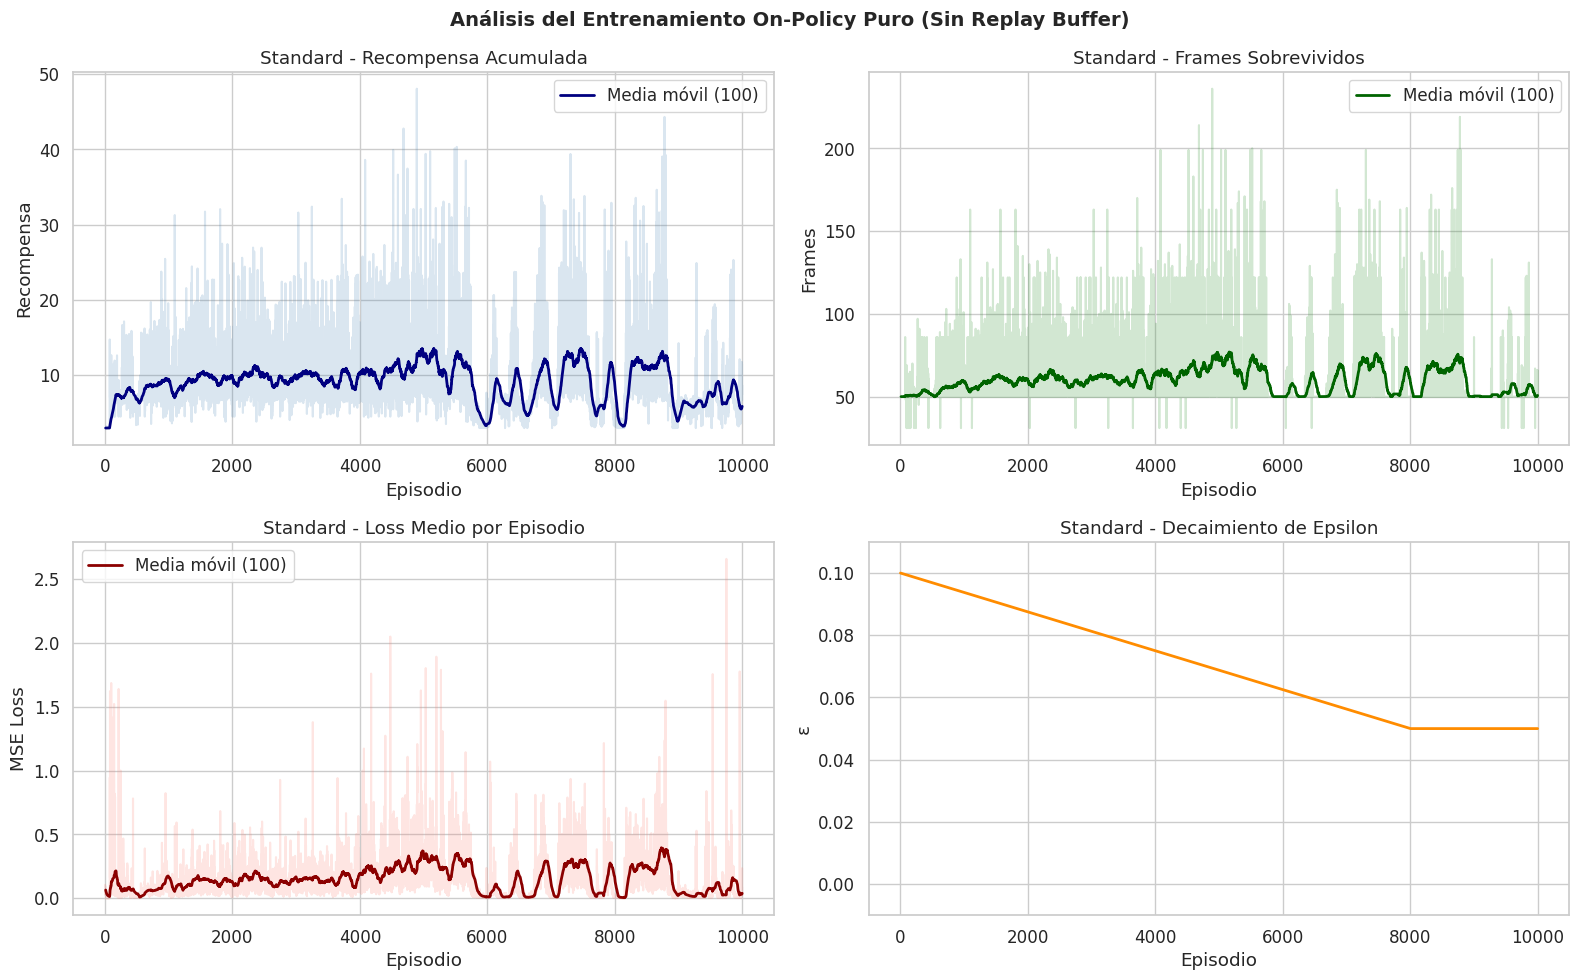

In [4]:
if not df_std.empty:
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Recompensa Acumulada
    axes[0,0].plot(df_std['episode'], df_std['reward'], alpha=0.2, color='steelblue')
    axes[0,0].plot(df_std['episode'], df_std['reward'].rolling(100, min_periods=10).mean(), color='navy', linewidth=2, label='Media móvil (100)')
    axes[0,0].set_title("Standard - Recompensa Acumulada")
    axes[0,0].set_xlabel("Episodio")
    axes[0,0].set_ylabel("Recompensa")
    axes[0,0].legend()
    
    # Frames Sobrevividos
    axes[0,1].plot(df_std['episode'], df_std['steps'], alpha=0.2, color='forestgreen')
    axes[0,1].plot(df_std['episode'], df_std['steps'].rolling(100, min_periods=10).mean(), color='darkgreen', linewidth=2, label='Media móvil (100)')
    axes[0,1].set_title("Standard - Frames Sobrevividos")
    axes[0,1].set_xlabel("Episodio")
    axes[0,1].set_ylabel("Frames")
    axes[0,1].legend()
    
    # Loss medio por episodio
    axes[1,0].plot(df_std['episode'], df_std['avg_loss'], alpha=0.2, color='salmon')
    axes[1,0].plot(df_std['episode'], df_std['avg_loss'].rolling(100, min_periods=10).mean(), color='darkred', linewidth=2, label='Media móvil (100)')
    axes[1,0].set_title("Standard - Loss Medio por Episodio")
    axes[1,0].set_xlabel("Episodio")
    axes[1,0].set_ylabel("MSE Loss")
    axes[1,0].legend()
    
    # Epsilon decay
    axes[1,1].plot(df_std['episode'], df_std['epsilon'], color='darkorange', linewidth=2)
    axes[1,1].set_title("Standard - Decaimiento de Epsilon")
    axes[1,1].set_xlabel("Episodio")
    axes[1,1].set_ylabel("ε")
    axes[1,1].set_ylim(-0.01, max(df_std['epsilon']) * 1.1)
    
    plt.suptitle("Análisis del Entrenamiento On-Policy Puro (Sin Replay Buffer)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Parte 2: Entrenamiento SARSA Semi-Gradiente con Replay Buffer

Al añadir un Replay Buffer, almacenamos las transiciones $(S, A, R, S', A')$ en una memoria cíclica de tamaño `BUFFER_CAPACITY`. En cada paso de entrenamiento:
1. Almacenamos la nueva transición
2. Muestreamos un mini-batch aleatorio del buffer
3. Actualizamos la red con ese batch -> menor varianza y decorrelación temporal.

Esto mitiga el olvido porque la red ve experiencias diversas en cada actualización, no sólo la transición más reciente.

In [5]:
env_rep = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False)
agent_rep = SemiGradientSarsaAgent(env_rep, alpha=LEARNING_RATE, gamma=GAMMA, epsilon=EPSILON_START, hidden_dim=64)
replay_buffer = ReplayBuffer(capacity=BUFFER_CAPACITY, state_dim=12)
metrics_rep = []

if TRAIN_REPLAY:
    print(f"Iniciando entrenamiento REPLAY BUFFER: {NUM_EPISODES} episodios...")
    start_time = time.time()
    
    # decay_rate es constante — se calcula una sola vez fuera del bucle
    decay_rate = max(0, (EPSILON_START - EPSILON_END) / EPSILON_DECAY_EPISODES)
    
    for episode in range(NUM_EPISODES):
        state, _ = env_rep.reset()
        action = agent_rep.get_action(state)
        
        total_reward = 0
        steps = 0
        total_loss = 0.0
        updates = 0
        done = False
        
        # Decaimiento lineal de epsilon
        agent_rep.epsilon = max(EPSILON_END, EPSILON_START - decay_rate * episode)
        
        while not done:
            next_state, reward, terminated, truncated, info = env_rep.step(action)
            done = terminated or truncated
            
            next_action = agent_rep.get_action(next_state) if not done else 0
            # Almacenamos la transición SARSA completa (S, A, R, S', A') en el buffer
            replay_buffer.add(state, action, reward, next_state, next_action, done)
            
            # Solo entrenamos si hay suficientes experiencias en el buffer
            if len(replay_buffer) > MIN_BUFFER_SIZE:
                b_states, b_actions, b_rewards, b_next_states, b_next_actions, b_dones = replay_buffer.sample(BATCH_SIZE)
                # update_batch: misma lógica semi-gradiente pero con un batch de experiencias
                loss = agent_rep.update_batch(b_states, b_actions, b_rewards, b_next_states, b_next_actions, b_dones)
                total_loss += loss
                updates += 1
                
            state = next_state
            action = next_action
            
            total_reward += reward
            steps += 1
            
        metrics_rep.append({
            "episode": episode + 1,
            "reward": total_reward,
            "steps": steps,
            "epsilon": agent_rep.epsilon,
            "avg_loss": total_loss / updates if updates > 0 else 0
        })
        
        if (episode + 1) % 500 == 0:
            print(f"[Ep: {episode+1}/{NUM_EPISODES}] | Recompensa: {total_reward:6.1f} | Frames: {steps:4d} | Epsilon: {agent_rep.epsilon:.3f} | Loss: {metrics_rep[-1]['avg_loss']:.4f}")
                
    agent_rep.save_weights("models/sarsa_rep_weights.pth")
    df_rep = pd.DataFrame(metrics_rep)
    df_rep.to_csv("results/sarsa_rep_metrics.csv", index=False)
    print(f"\nEntrenamiento completado en {time.time() - start_time:.2f} segundos.\n")
else:
    print("Cargando pesos REPLAY preexistentes...")
    agent_rep.load_weights("models/sarsa_rep_weights.pth")
    if os.path.exists("results/sarsa_rep_metrics.csv"):
        df_rep = pd.read_csv("results/sarsa_rep_metrics.csv")
    else:
        df_rep = pd.DataFrame()

Iniciando entrenamiento REPLAY BUFFER: 10000 episodios...
[Ep: 500/10000] | Recompensa:   10.9 | Frames:   65 | Epsilon: 0.097 | Loss: 0.1965
[Ep: 1000/10000] | Recompensa:    8.3 | Frames:   50 | Epsilon: 0.094 | Loss: 0.2511
[Ep: 1500/10000] | Recompensa:    8.3 | Frames:   52 | Epsilon: 0.091 | Loss: 0.2510
[Ep: 2000/10000] | Recompensa:    9.6 | Frames:   58 | Epsilon: 0.088 | Loss: 0.3294
[Ep: 2500/10000] | Recompensa:   12.2 | Frames:   66 | Epsilon: 0.084 | Loss: 0.3976
[Ep: 3000/10000] | Recompensa:   17.2 | Frames:   94 | Epsilon: 0.081 | Loss: 0.4248
[Ep: 3500/10000] | Recompensa:    8.2 | Frames:   51 | Epsilon: 0.078 | Loss: 0.4026
[Ep: 4000/10000] | Recompensa:    7.5 | Frames:   50 | Epsilon: 0.075 | Loss: 0.4361
[Ep: 4500/10000] | Recompensa:    8.3 | Frames:   52 | Epsilon: 0.072 | Loss: 0.4731
[Ep: 5000/10000] | Recompensa:    9.9 | Frames:   61 | Epsilon: 0.069 | Loss: 0.4201
[Ep: 5500/10000] | Recompensa:   42.1 | Frames:  211 | Epsilon: 0.066 | Loss: 0.5030
[Ep: 600

### Análisis Gráfico Replay Buffer

Con el Replay Buffer deberíamos observar:
- Convergencia más estable y menos ruidosa
- Loss decreciente sostenido
- Mayor promedio de frames sobrevividos frente al estándar

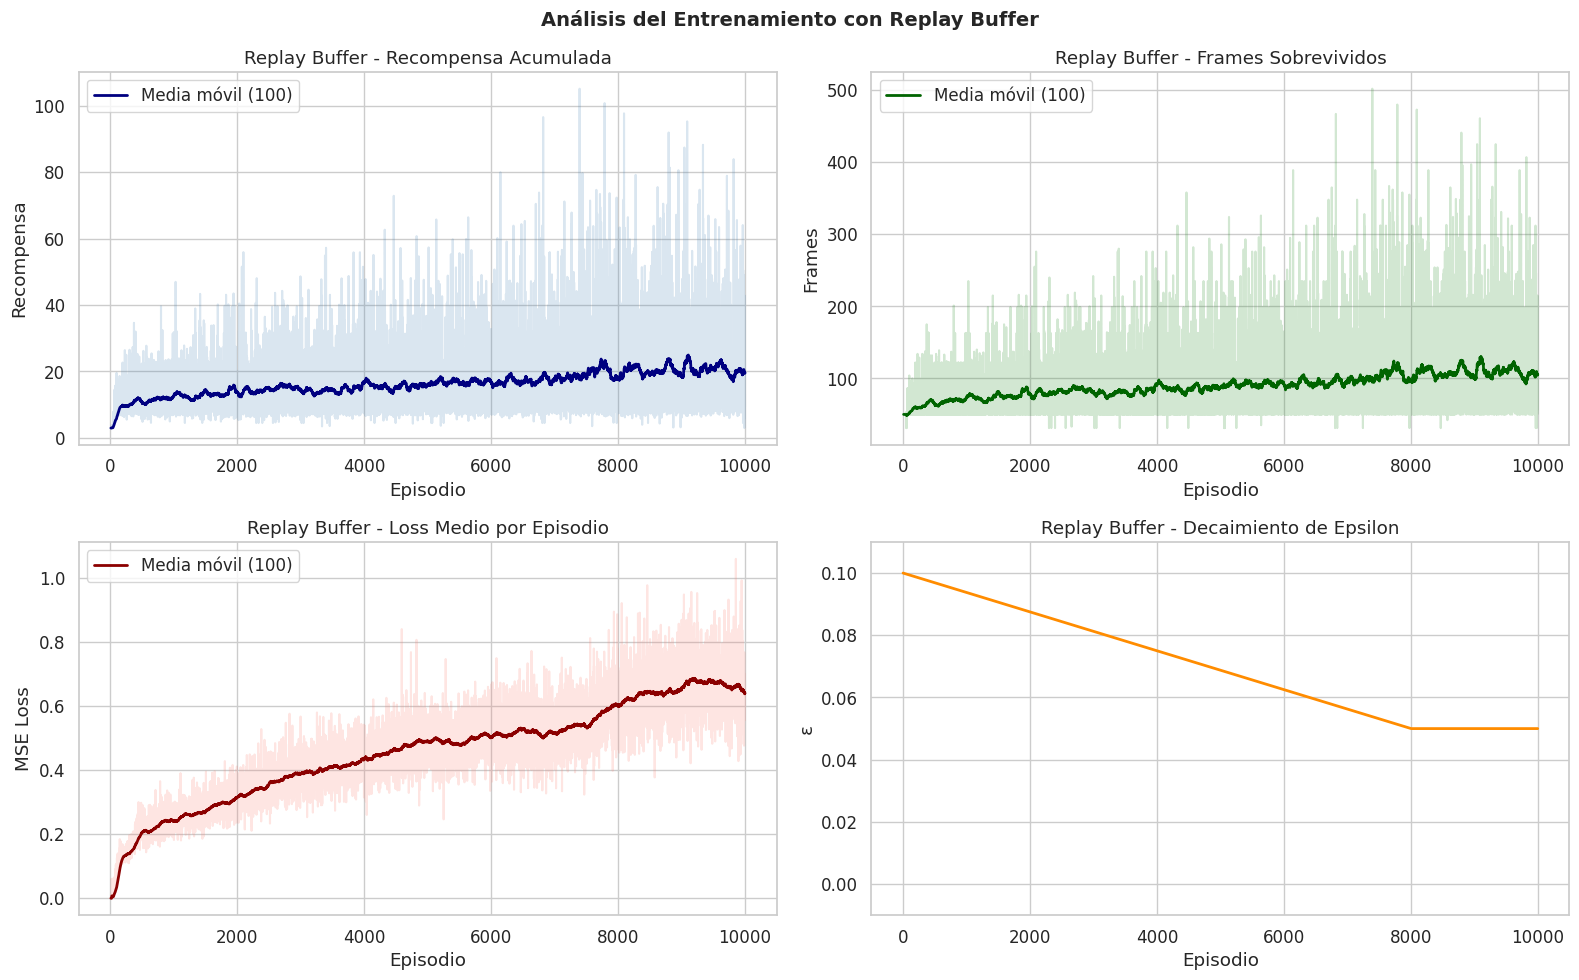

In [6]:
if not df_rep.empty:
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Recompensa Acumulada
    axes[0,0].plot(df_rep['episode'], df_rep['reward'], alpha=0.2, color='steelblue')
    axes[0,0].plot(df_rep['episode'], df_rep['reward'].rolling(100, min_periods=10).mean(), color='navy', linewidth=2, label='Media móvil (100)')
    axes[0,0].set_title("Replay Buffer - Recompensa Acumulada")
    axes[0,0].set_xlabel("Episodio")
    axes[0,0].set_ylabel("Recompensa")
    axes[0,0].legend()
    
    # Frames
    axes[0,1].plot(df_rep['episode'], df_rep['steps'], alpha=0.2, color='forestgreen')
    axes[0,1].plot(df_rep['episode'], df_rep['steps'].rolling(100, min_periods=10).mean(), color='darkgreen', linewidth=2, label='Media móvil (100)')
    axes[0,1].set_title("Replay Buffer - Frames Sobrevividos")
    axes[0,1].set_xlabel("Episodio")
    axes[0,1].set_ylabel("Frames")
    axes[0,1].legend()
    
    # Loss
    axes[1,0].plot(df_rep['episode'], df_rep['avg_loss'], alpha=0.2, color='salmon')
    axes[1,0].plot(df_rep['episode'], df_rep['avg_loss'].rolling(100, min_periods=10).mean(), color='darkred', linewidth=2, label='Media móvil (100)')
    axes[1,0].set_title("Replay Buffer - Loss Medio por Episodio")
    axes[1,0].set_xlabel("Episodio")
    axes[1,0].set_ylabel("MSE Loss")
    axes[1,0].legend()
    
    # Epsilon decay
    axes[1,1].plot(df_rep['episode'], df_rep['epsilon'], color='darkorange', linewidth=2)
    axes[1,1].set_title("Replay Buffer - Decaimiento de Epsilon")
    axes[1,1].set_xlabel("Episodio")
    axes[1,1].set_ylabel("ε")
    axes[1,1].set_ylim(-0.01, max(df_rep['epsilon']) * 1.1)
    
    plt.suptitle("Análisis del Entrenamiento con Replay Buffer", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Parte 3: Análisis Comparativo Detallado

Comparamos los dos enfoques de forma directa:
- Recompensa: ¿cuál acumula más recompensa por episodio?
- Supervivencia: ¿cuál sobrevive más frames?
- Estabilidad: ¿cuál tiene menor varianza en el rendimiento?
- Eficiencia: ¿cuál converge más rápido?

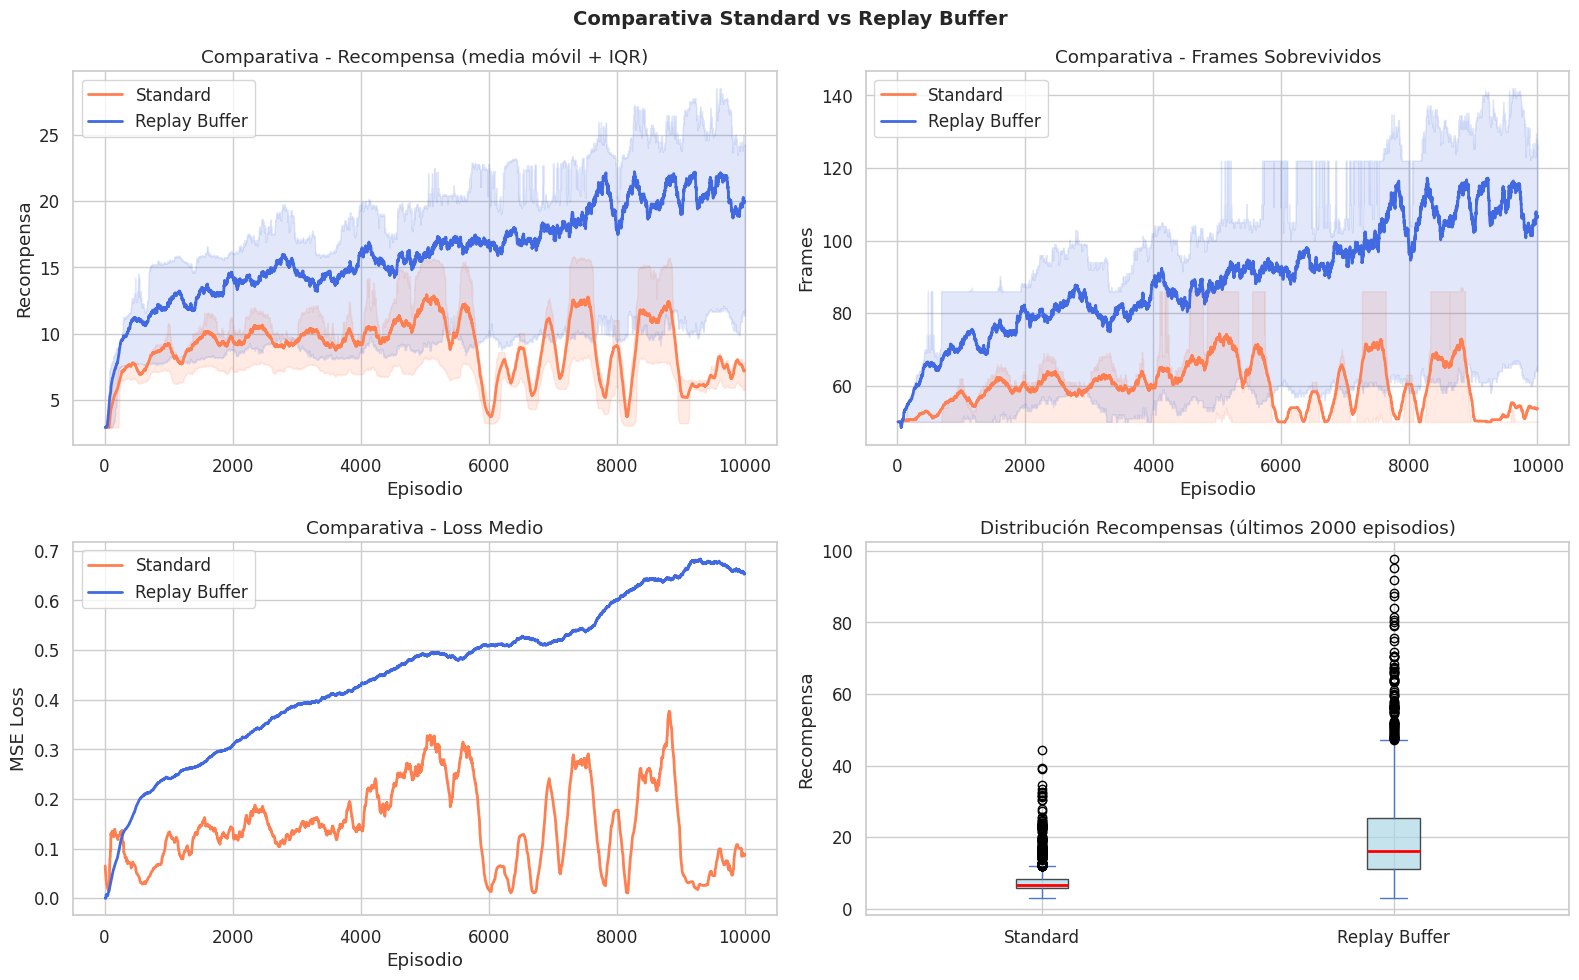

In [7]:
if not df_std.empty and not df_rep.empty:
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    window = 200
    
    # === Recompensa comparativa ===
    std_smooth_r = df_std['reward'].rolling(window, min_periods=10).mean()
    rep_smooth_r = df_rep['reward'].rolling(window, min_periods=10).mean()
    axes[0,0].plot(df_std['episode'], std_smooth_r, color='coral', linewidth=2, label='Standard')
    axes[0,0].plot(df_rep['episode'], rep_smooth_r, color='royalblue', linewidth=2, label='Replay Buffer')
    axes[0,0].fill_between(df_std['episode'], 
                            df_std['reward'].rolling(window, min_periods=10).quantile(0.25),
                            df_std['reward'].rolling(window, min_periods=10).quantile(0.75),
                            alpha=0.15, color='coral')
    axes[0,0].fill_between(df_rep['episode'],
                            df_rep['reward'].rolling(window, min_periods=10).quantile(0.25),
                            df_rep['reward'].rolling(window, min_periods=10).quantile(0.75),
                            alpha=0.15, color='royalblue')
    axes[0,0].set_title("Comparativa - Recompensa (media móvil + IQR)")
    axes[0,0].set_xlabel("Episodio")
    axes[0,0].set_ylabel("Recompensa")
    axes[0,0].legend()
    
    # === Frames comparativa ===
    std_smooth_s = df_std['steps'].rolling(window, min_periods=10).mean()
    rep_smooth_s = df_rep['steps'].rolling(window, min_periods=10).mean()
    axes[0,1].plot(df_std['episode'], std_smooth_s, color='coral', linewidth=2, label='Standard')
    axes[0,1].plot(df_rep['episode'], rep_smooth_s, color='royalblue', linewidth=2, label='Replay Buffer')
    axes[0,1].fill_between(df_std['episode'],
                            df_std['steps'].rolling(window, min_periods=10).quantile(0.25),
                            df_std['steps'].rolling(window, min_periods=10).quantile(0.75),
                            alpha=0.15, color='coral')
    axes[0,1].fill_between(df_rep['episode'],
                            df_rep['steps'].rolling(window, min_periods=10).quantile(0.25),
                            df_rep['steps'].rolling(window, min_periods=10).quantile(0.75),
                            alpha=0.15, color='royalblue')
    axes[0,1].set_title("Comparativa - Frames Sobrevividos")
    axes[0,1].set_xlabel("Episodio")
    axes[0,1].set_ylabel("Frames")
    axes[0,1].legend()
    
    # === Loss comparativa ===
    std_smooth_l = df_std['avg_loss'].rolling(window, min_periods=10).mean()
    rep_smooth_l = df_rep['avg_loss'].rolling(window, min_periods=10).mean()
    axes[1,0].plot(df_std['episode'], std_smooth_l, color='coral', linewidth=2, label='Standard')
    axes[1,0].plot(df_rep['episode'], rep_smooth_l, color='royalblue', linewidth=2, label='Replay Buffer')
    axes[1,0].set_title("Comparativa - Loss Medio")
    axes[1,0].set_xlabel("Episodio")
    axes[1,0].set_ylabel("MSE Loss")
    axes[1,0].legend()
    
    # === Distribución de recompensas (últimos 2000 episodios) ===
    tail = 2000
    if len(df_std) >= tail and len(df_rep) >= tail:
        data_box = pd.DataFrame({
            'Standard': df_std['reward'].tail(tail).values,
            'Replay Buffer': df_rep['reward'].tail(tail).values
        })
        data_box.plot.box(ax=axes[1,1], patch_artist=True,
                          boxprops=dict(facecolor='lightblue', alpha=0.7),
                          medianprops=dict(color='red', linewidth=2))
        axes[1,1].set_title(f"Distribución Recompensas (últimos {tail} episodios)")
        axes[1,1].set_ylabel("Recompensa")
    else:
        axes[1,1].text(0.5, 0.5, "Datos insuficientes", ha='center', va='center', fontsize=14)
        axes[1,1].set_title("Distribución Recompensas")
    
    plt.suptitle("Comparativa Standard vs Replay Buffer", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Resumen Estadístico

Tabla comparativa con estadísticas clave de ambos métodos de entrenamiento.

In [8]:
def compute_stats(df, name, tail=2000):
    """Computa estadísticas para la cola del entrenamiento."""
    if df.empty or len(df) < tail:
        print(f"  {name}: datos insuficientes (tiene {len(df)} episodios, necesita {tail})")
        return None
    
    tail_df = df.tail(tail)
    return {
        'Método': name,
        'Recompensa Media': f"{tail_df['reward'].mean():.2f}",
        'Recompensa Std': f"{tail_df['reward'].std():.2f}",
        'Recompensa Max': f"{tail_df['reward'].max():.2f}",
        'Recompensa Mediana': f"{tail_df['reward'].median():.2f}",
        'Frames Medio': f"{tail_df['steps'].mean():.1f}",
        'Frames Std': f"{tail_df['steps'].std():.1f}",
        'Frames Max': f"{tail_df['steps'].max():.0f}",
        'Loss Medio': f"{tail_df['avg_loss'].mean():.4f}",
        'Loss Std': f"{tail_df['avg_loss'].std():.4f}",
    }

rows = []
for df, name in [(df_std, 'Standard'), (df_rep, 'Replay Buffer')]:
    s = compute_stats(df, name)
    if s: rows.append(s)

if rows:
    summary_df = pd.DataFrame(rows).set_index('Método')
    display(summary_df.T)
else:
    print("No hay datos suficientes para generar la tabla comparativa.")

Método,Standard,Replay Buffer
Recompensa Media,8.02,20.51
Recompensa Std,4.50,13.31
Recompensa Max,44.31,97.74
Recompensa Mediana,6.78,16.26
Frames Medio,57.2,109.2
Frames Std,17.6,62.4
Frames Max,219,473
Loss Medio,0.1266,0.6535
Loss Std,0.1825,0.0820


### Análisis por Fases de Entrenamiento

Dividimos el entrenamiento en 3 fases (temprana, intermedia, tardía) para ver cómo evoluciona el rendimiento.

/tmp/ipykernel_69037/2621990832.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(reward_data, labels=list(phases.keys()), patch_artist=True,
/tmp/ipykernel_69037/2621990832.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(steps_data, labels=list(phases.keys()), patch_artist=True,


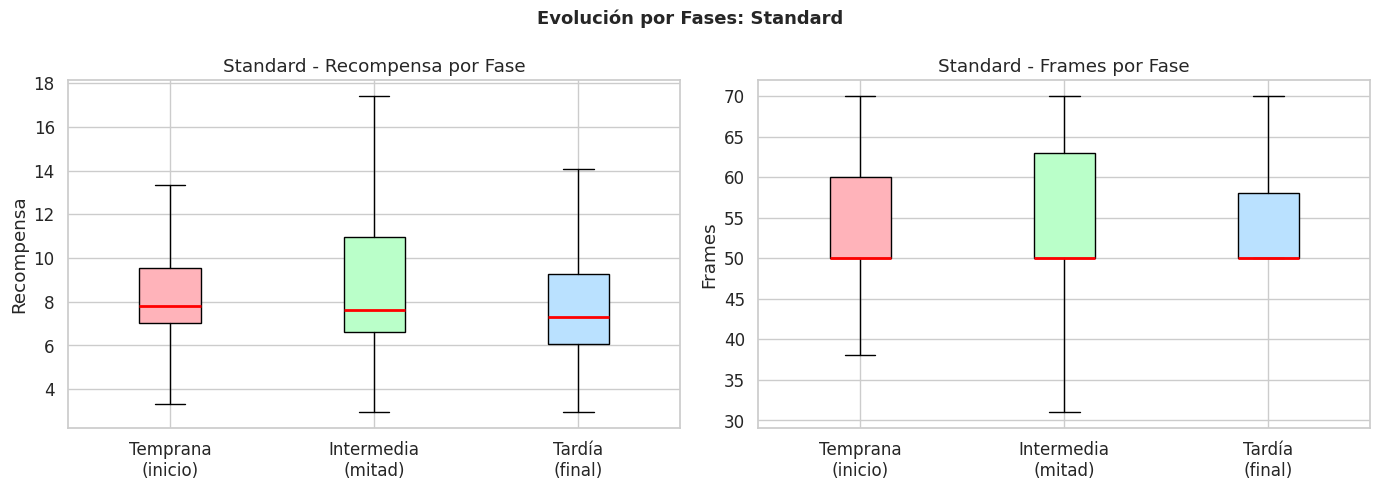

  Temprana (inicio): reward=8.97±3.57, frames=57.9±15.1
  Intermedia (mitad): reward=9.37±5.09, frames=61.6±21.4
  Tardía (final): reward=8.59±4.79, frames=58.8±18.9


/tmp/ipykernel_69037/2621990832.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(reward_data, labels=list(phases.keys()), patch_artist=True,
/tmp/ipykernel_69037/2621990832.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(steps_data, labels=list(phases.keys()), patch_artist=True,


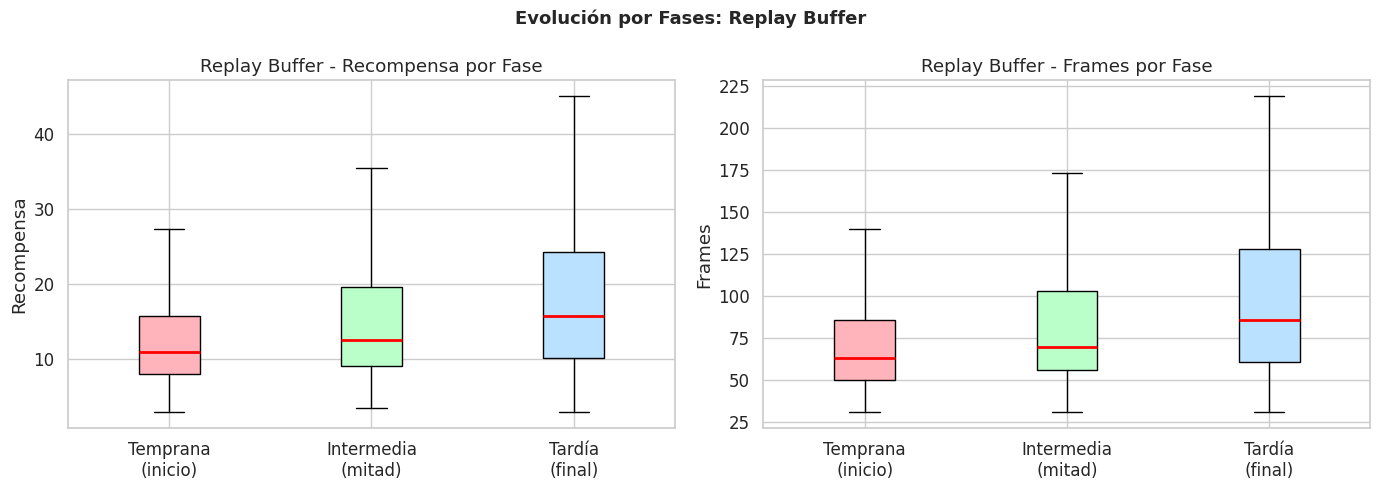

  Temprana (inicio): reward=12.93±6.74, frames=74.5±30.8
  Intermedia (mitad): reward=16.06±9.52, frames=88.5±44.6
  Tardía (final): reward=19.82±13.17, frames=105.9±61.8


In [9]:
def phase_analysis(df, name):
    """Divide el entrenamiento en 3 fases y genera boxplots de recompensa y frames."""
    if df.empty or len(df) < 100:
        print(f"  {name}: datos insuficientes")
        return
    
    n = len(df)
    third = n // 3
    
    phases = {
        'Temprana\n(inicio)': df.iloc[:third],
        'Intermedia\n(mitad)': df.iloc[third:2*third],
        'Tardía\n(final)': df.iloc[2*third:]
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot de recompensas por fase
    reward_data = [p['reward'].values for p in phases.values()]
    bp1 = ax1.boxplot(reward_data, labels=list(phases.keys()), patch_artist=True,
                       showfliers=False, medianprops=dict(color='red', linewidth=2))
    colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF']
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    ax1.set_title(f"{name} - Recompensa por Fase")
    ax1.set_ylabel("Recompensa")
    
    # Boxplot de frames por fase
    steps_data = [p['steps'].values for p in phases.values()]
    bp2 = ax2.boxplot(steps_data, labels=list(phases.keys()), patch_artist=True,
                       showfliers=False, medianprops=dict(color='red', linewidth=2))
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
    ax2.set_title(f"{name} - Frames por Fase")
    ax2.set_ylabel("Frames")
    
    plt.suptitle(f"Evolución por Fases: {name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Estadísticas por fase
    for phase_name, phase_df in phases.items():
        clean_name = phase_name.replace('\n', ' ')
        print(f"  {clean_name}: reward={phase_df['reward'].mean():.2f}±{phase_df['reward'].std():.2f}, "
              f"frames={phase_df['steps'].mean():.1f}±{phase_df['steps'].std():.1f}")

if not df_std.empty:
    phase_analysis(df_std, "Standard")
if not df_rep.empty:
    phase_analysis(df_rep, "Replay Buffer")

### Histograma de Distribución de Recompensas

Visualización de la distribución completa de recompensas para entender la forma de la distribución y la presencia de outliers.

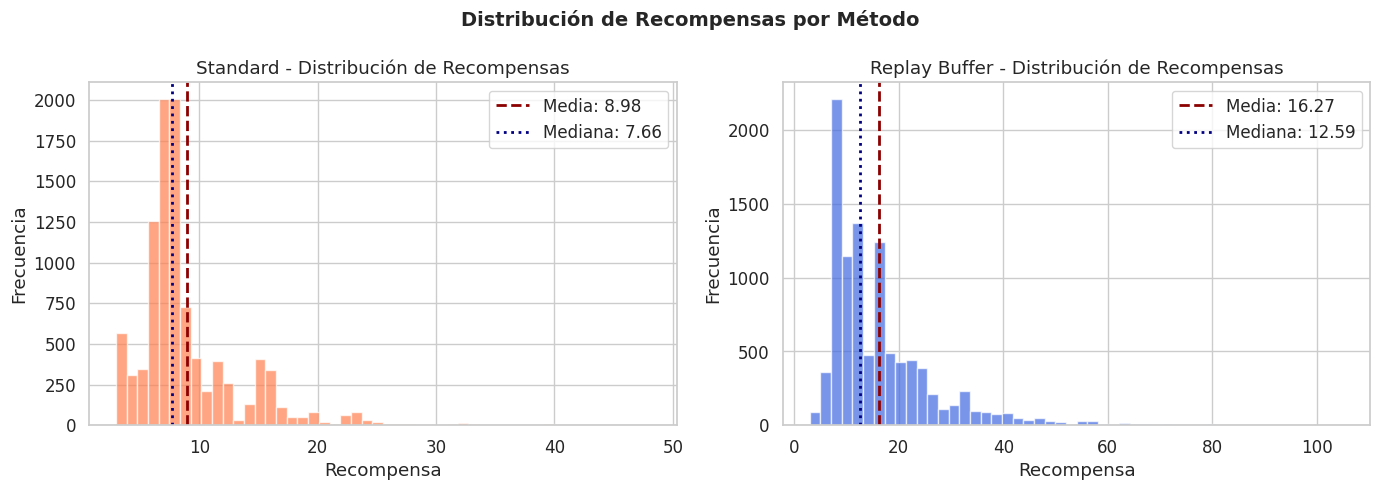

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if not df_std.empty:
    ax1.hist(df_std['reward'], bins=50, color='coral', alpha=0.7, edgecolor='white')
    ax1.axvline(df_std['reward'].mean(), color='darkred', linestyle='--', linewidth=2, label=f"Media: {df_std['reward'].mean():.2f}")
    ax1.axvline(df_std['reward'].median(), color='navy', linestyle=':', linewidth=2, label=f"Mediana: {df_std['reward'].median():.2f}")
    ax1.set_title("Standard - Distribución de Recompensas")
    ax1.set_xlabel("Recompensa")
    ax1.set_ylabel("Frecuencia")
    ax1.legend()

if not df_rep.empty:
    ax2.hist(df_rep['reward'], bins=50, color='royalblue', alpha=0.7, edgecolor='white')
    ax2.axvline(df_rep['reward'].mean(), color='darkred', linestyle='--', linewidth=2, label=f"Media: {df_rep['reward'].mean():.2f}")
    ax2.axvline(df_rep['reward'].median(), color='navy', linestyle=':', linewidth=2, label=f"Mediana: {df_rep['reward'].median():.2f}")
    ax2.set_title("Replay Buffer - Distribución de Recompensas")
    ax2.set_xlabel("Recompensa")
    ax2.set_ylabel("Frecuencia")
    ax2.legend()

plt.suptitle("Distribución de Recompensas por Método", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 4: Evaluación Lógica (Testing Greedy)

Para evaluar el rendimiento real del agente, fijamos $\epsilon = 0$ (política completamente greedy, sin exploración aleatoria) y ejecutamos múltiples episodios.

Esto nos da una estimación limpia de lo que el agente ha realmente aprendido, sin el ruido de la exploración.

In [11]:
agent_std.epsilon = 0.0
agent_rep.epsilon = 0.0

def eval_agent(agent_env, agent_model, name):
    test_rewards, test_steps, test_scores = [], [], []
    for ep in range(NUM_TEST_EPISODES):
        state, _ = agent_env.reset()
        done, total_r, steps, score = False, 0, 0, 0
        while not done:
            action = agent_model.get_action(state)
            state, reward, terminated, truncated, info = agent_env.step(action)
            done = terminated or truncated
            total_r += reward
            steps += 1
            if done: score = info.get('score', 0)
        test_rewards.append(total_r)
        test_steps.append(steps)
        test_scores.append(score)
    
    print(f"\n--- RESULTADOS {name} ({NUM_TEST_EPISODES} episodios greedy) ---")
    print(f"Supervivencia Media : {np.mean(test_steps):8.2f} frames ± {np.std(test_steps):6.2f}")
    print(f"Supervivencia Max   : {np.max(test_steps):8.0f} frames")
    print(f"Recompensa Media    : {np.mean(test_rewards):8.2f} ± {np.std(test_rewards):6.2f}")
    print(f"Tuberías Superadas  : {np.mean(test_scores):8.2f} obstáculos ± {np.std(test_scores):6.2f}")
    print(f"Tuberías Max        : {np.max(test_scores):8.0f} obstáculos")
    return test_rewards, test_steps, test_scores

std_results = eval_agent(env, agent_std, "STANDARD SARSA")
rep_results = eval_agent(env_rep, agent_rep, "REPLAY BUFFER SARSA")


--- RESULTADOS STANDARD SARSA (50 episodios greedy) ---
Supervivencia Media :    53.72 frames ±   3.24
Supervivencia Max   :       59 frames
Recompensa Media    :     8.47 ±   0.54
Tuberías Superadas  :     0.00 obstáculos ±   0.00
Tuberías Max        :        0 obstáculos

--- RESULTADOS REPLAY BUFFER SARSA (50 episodios greedy) ---
Supervivencia Media :  7479.80 frames ± 5670.51
Supervivencia Max   :    25059 frames
Recompensa Media    :  1583.86 ± 1202.59
Tuberías Superadas  :   197.30 obstáculos ± 150.54
Tuberías Max        :      664 obstáculos


### Comparativa Visual de Evaluación

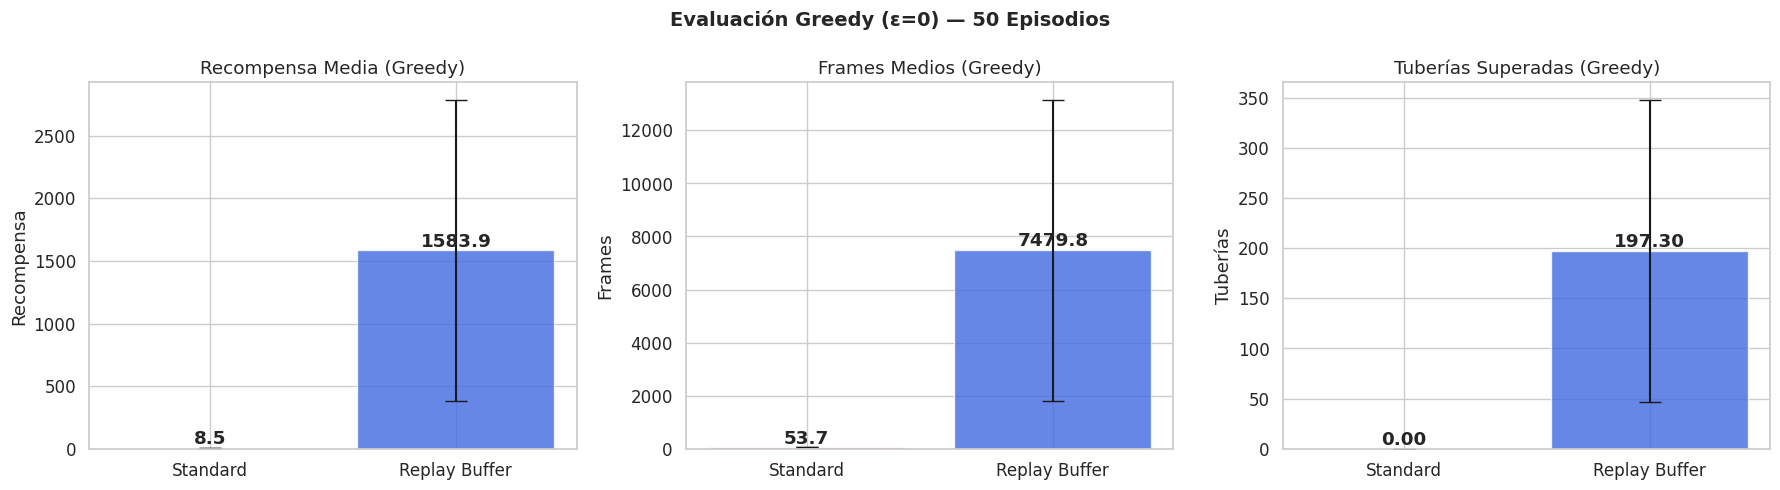

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rewards comparison
labels = ['Standard', 'Replay Buffer']
means_r = [np.mean(std_results[0]), np.mean(rep_results[0])]
stds_r = [np.std(std_results[0]), np.std(rep_results[0])]
bars1 = axes[0].bar(labels, means_r, yerr=stds_r, capsize=8, color=['coral', 'royalblue'], alpha=0.8, edgecolor='white')
axes[0].set_title("Recompensa Media (Greedy)")
axes[0].set_ylabel("Recompensa")
for bar, mean in zip(bars1, means_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

# Steps comparison
means_s = [np.mean(std_results[1]), np.mean(rep_results[1])]
stds_s = [np.std(std_results[1]), np.std(rep_results[1])]
bars2 = axes[1].bar(labels, means_s, yerr=stds_s, capsize=8, color=['coral', 'royalblue'], alpha=0.8, edgecolor='white')
axes[1].set_title("Frames Medios (Greedy)")
axes[1].set_ylabel("Frames")
for bar, mean in zip(bars2, means_s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

# Scores comparison
means_sc = [np.mean(std_results[2]), np.mean(rep_results[2])]
stds_sc = [np.std(std_results[2]), np.std(rep_results[2])]
bars3 = axes[2].bar(labels, means_sc, yerr=stds_sc, capsize=8, color=['coral', 'royalblue'], alpha=0.8, edgecolor='white')
axes[2].set_title("Tuberías Superadas (Greedy)")
axes[2].set_ylabel("Tuberías")
for bar, mean in zip(bars3, means_sc):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle(f"Evaluación Greedy (ε=0) — {NUM_TEST_EPISODES} Episodios", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 5: Render Visual del mejor modelo (Replay Buffer)

Visualización en tiempo real del agente entrenado jugando a Flappy Bird.

In [13]:
try:
    env_vis = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False, render_mode="human")
except Exception as e:
    env_vis = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False, render_mode=None)

evaluate_flappy_bird_agent(agent_rep, env_vis, num_episodes=NUM_RENDER_EPISODES, render=(env_vis.render_mode == "human"), fps=45)

try:
    env_vis.close()
except Exception:
    pass

[Visual-Ep 1] Agente colisionó en el timestep 10143. Puntuación final: 268
[Visual-Ep 2] Agente colisionó en el timestep 7092. Puntuación final: 187
[Visual-Ep 3] Agente colisionó en el timestep 2120. Puntuación final: 55


## Conclusiones

### Sobre el Algoritmo
- Semi-Gradient SARSA es eficaz para espacios de estados continuos cuando se combina con una red neuronal como aproximador de la función Q.
- El enfoque semi-gradiente (tratar el target como constante) es necesario para la estabilidad del entrenamiento.

### Sobre el Replay Buffer
- Sin Replay Buffer, la red neuronal sufre de olvido: al entrenar sólo con la transición más reciente, los pesos de la red se sobreescriben continuamente, olvidando lo aprendido.
- Con Replay Buffer, la convergencia es más estable y más rápida, al decorrelacionar las muestras de entrenamiento.

### Sobre los Hiperparámetros
- Un $\epsilon$ inicial bajo (0.1) permite al agente explotar rápidamente lo aprendido, crucial en un entorno donde la supervivencia es corta al principio.
- El reward shaping (proximidad al centro del gap) proporciona señales de aprendizaje más densas que la recompensa binaria original.

### Limitaciones
- SARSA Semi-Gradiente no garantiza convergencia como los métodos tabulares; la calidad depende de la arquitectura de la red y los hiperparámetros.
- El uso de Replay Buffer introduce un sesgo off-policy que puede no ser ideal para todos los entornos.
- En este entorno particular, la duración de los episodios es muy corta al inicio (el pájaro choca rápido), lo que dificulta la recopilación de experiencias diversas.